# 4장 실습 — 시스템 식별

3장에서 자를 만들었다. 이제 그 자로 채점받을 첫 기법이다.

시스템 식별은 가장 곧은 길이다. 시뮬이 실기와 다르다면 시뮬의 파라미터를 실기 값으로 맞춘다. 마찰이 얼마인지 모르니 실기에서 궤적을 몇 개 받아 역으로 추정한다.

이 노트북은 같은 추정 문제를 **두 가지 방식으로** 푼다. 하나는 과제 궤적을 그대로 써서 세 파라미터를 한 번에 추정하는 방식이고, 다른 하나는 파라미터마다 그것이 잘 드러나는 실험을 따로 설계하는 방식이다. 옵티마이저도 예산도 같다. 결과는 크게 갈린다.

그리고 마지막에 3장의 자로 채점한다. 거기서 한 번 더 놀라게 된다.

실행 시간은 CPU에서 3분 안팎이다.

In [1]:
%pip install -q mujoco==3.13.0 koreanize-matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import unicodedata
import numpy as np
import mujoco
import matplotlib.pyplot as plt
import koreanize_matplotlib  # noqa: F401


def dw(s):
    # 화면에서 차지하는 칸 수. 한글은 한 글자가 두 칸이다
    return sum(2 if unicodedata.east_asian_width(c) in "WF" else 1
               for c in str(s))


def pad(s, n, right=False):
    # f"{s:<12}" 는 글자 수로 세어 한글 표를 어긋나게 한다
    gap = " " * max(n - dw(s), 0)
    return gap + str(s) if right else str(s) + gap


RED, GREY, INK = "#E32C24", "#8C8A85", "#1C1C1A"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})
print("mujoco", mujoco.__version__)

mujoco 3.13.0


## 실험대 — 3장과 같은 것

같은 평면 밀기를 쓴다. 「실기」는 3장에서 정한 그대로다 — 마찰 0.6, 게인 120, 관측 잡음 4mm, 제어 지연 2스텝. 다만 이번에는 **그 값을 모른다고 치고** 되찾는 것이 목표다. 참값을 아는 것이 이 노트북의 이점이고, 진짜 로봇으로는 못 하는 일이다.

In [3]:
XML = '''
<mujoco model="planar_push">
  <option timestep="0.004" integrator="implicitfast"/>
  <worldbody>
    <geom name="floor" type="plane" size="3 3 .1"
          friction="{mu} .005 .0001"/>
    <body name="block" pos="0 0 .031">
      <freejoint/>
      <geom name="block" type="cylinder" size=".03 .03" mass=".25"
            friction="{mu} .005 .0001"/>
    </body>
    <body name="pusher" pos="0 0 .03">
      <joint name="px" type="slide" axis="1 0 0"/>
      <joint name="py" type="slide" axis="0 1 0"/>
      <geom name="pusher" type="cylinder" size=".012 .03" mass="4"/>
    </body>
  </worldbody>
  <actuator>
    <velocity joint="px" kv="{kv}"/>
    <velocity joint="py" kv="{kv}"/>
  </actuator>
</mujoco>
'''

CTRL_HZ, EP_STEPS = 20, 140
GOAL_R, STANDOFF, STOP = .04, .045, .015
REAL = dict(mu=.60, kv=120., lat=2)     # 되찾아야 할 참값
NOISE = .004                            # 관측 잡음


def make(mu, kv):
    m = mujoco.MjModel.from_xml_string(XML.format(mu=mu, kv=kv))
    return m, mujoco.MjData(m)


def unit(v):
    n = np.linalg.norm(v)
    return v / n if n > 1e-9 else np.zeros_like(v)


def reset(m, d, rng):
    mujoco.mj_resetData(m, d)
    bx, by = rng.uniform(-.03, .03, 2)
    d.qpos[0:2] = [bx, by]
    d.qpos[2] = .031
    d.qpos[7:9] = [bx - .09, by]
    mujoco.mj_forward(m, d)
    return np.array([.28, 0.]) + rng.uniform(-.04, .04, 2)

## 방법 A — 과제 궤적으로 한 번에

가장 자연스러운 접근이다. 실기에서 밀기 궤적을 몇 개 받아, 같은 명령을 시뮬에서 재생하고 궤적이 맞을 때까지 파라미터를 흔든다.

정책을 그대로 굴려 받은 궤적은 쓰지 않는다. 정책이 목표에 닿으면 멈춰서 마찰이 드러날 구간이 짧고, 피드백이 오차를 지운다. 대신 앞으로 밀면서 좌우로 흔드는 **탐색용 개루프 명령**을 쓴다. 밀대가 원반에 계속 닿아 있으니 마찰이 드러나고, 좌우 진동이 액추에이터의 추종 특성을 드러낸다.

In [4]:
def excite(rng):
    # 앞으로 밀면서 좌우로 흔드는 개루프 명령
    period = rng.uniform(12, 30)
    phase = rng.uniform(0, 2 * np.pi)
    amp = rng.uniform(.08, .22)
    fwd = rng.uniform(.18, .32)
    t = np.arange(EP_STEPS)
    wig = amp * np.sin(2 * np.pi * t / period + phase)
    return np.stack([np.full(EP_STEPS, fwd), wig], 1)


def replay(m, d, rng, cmd, lat, noise=0.):
    # 주어진 명령을 그대로 재생하고 원반 궤적을 돌려준다
    reset(m, d, rng)
    sub = int(round(1 / CTRL_HZ / m.opt.timestep))
    buf = [np.zeros(2)] * (lat + 1)
    path = []
    for t in range(EP_STEPS):
        buf.append(cmd[t])
        d.ctrl[:] = buf[-1 - lat]
        for _ in range(sub):
            mujoco.mj_step(m, d)
        p = d.qpos[0:2].copy()
        if noise:
            p = p + rng.normal(0, noise, 2)
        path.append(p)
    return np.array(path)


N_TRAJ = 12
cmds = [excite(np.random.default_rng(500 + i))
        for i in range(N_TRAJ)]
mr, dr = make(REAL["mu"], REAL["kv"])
real_paths = [replay(mr, dr, np.random.default_rng(i), cmds[i],
                     REAL["lat"], NOISE) for i in range(N_TRAJ)]


def push_loss(mu, kv, lat, n=N_TRAJ):
    # 후보 파라미터로 실기 명령을 재생하고 궤적 차이를 잰다
    m, d = make(mu, kv)
    e = []
    for i in range(n):
        sp = replay(m, d, np.random.default_rng(i), cmds[i],
                    int(lat))
        e.append(np.linalg.norm(sp - real_paths[i], axis=1).mean())
    return float(np.mean(e))


print(f"실기 궤적 {N_TRAJ}개, 각 {EP_STEPS}스텝")
print(f"참값에서의 손실      {push_loss(**REAL)*1000:.2f} mm")
print(f"엉뚱한 값에서의 손실 {push_loss(.2, 300., 0)*1000:.2f} mm")

실기 궤적 12개, 각 140스텝


참값에서의 손실      4.91 mm


엉뚱한 값에서의 손실 15.32 mm


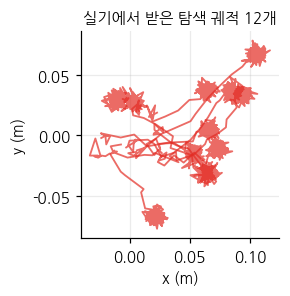

In [5]:
fig, ax = plt.subplots(figsize=(6.0, 2.8))
for p in real_paths:
    ax.plot(p[:, 0], p[:, 1], "-", color=RED, lw=1.2, alpha=.7)
ax.set_aspect("equal")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title("실기에서 받은 탐색 궤적 12개", fontsize=10)
plt.tight_layout()
plt.show()

## 손실 지형을 먼저 본다

추정을 돌리기 전에 손실이 어떻게 생겼는지 본다. 파라미터 하나씩만 바꿔 가며 그려 보면, 골짜기가 깊은 파라미터는 궤적에서 잘 드러나고 얕은 파라미터는 그렇지 않다.

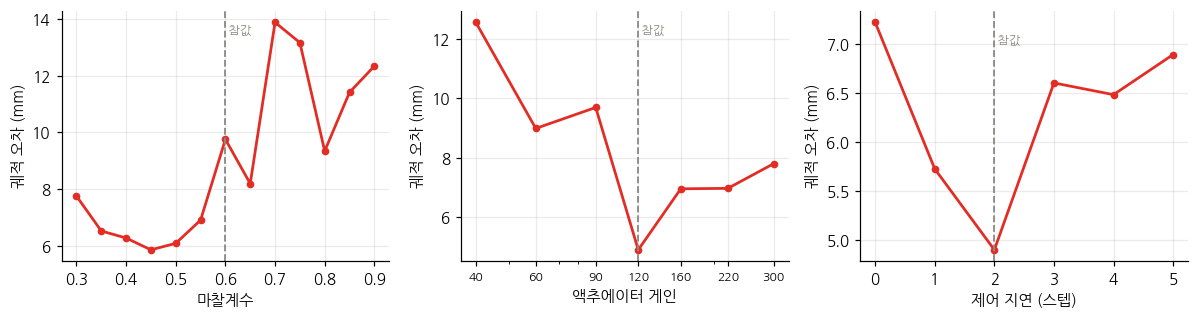

파라미터              최소점      참값   골짜기 깊이
마찰계수                0.45       0.6        8.0 mm
게인                     120       120        7.6 mm
지연                       2         2        2.3 mm


In [6]:
mus = np.linspace(.3, .9, 13)
kvs = np.array([40., 60., 90., 120., 160., 220., 300.])
lats = np.arange(0, 6)

L_mu = [push_loss(v, REAL["kv"], REAL["lat"], 8) for v in mus]
L_kv = [push_loss(REAL["mu"], v, REAL["lat"], 8) for v in kvs]
L_lat = [push_loss(REAL["mu"], REAL["kv"], v, 8) for v in lats]

fig, axes = plt.subplots(1, 3, figsize=(11.0, 3.0))
for ax, x, y, name, true in [
        (axes[0], mus, L_mu, "마찰계수", REAL["mu"]),
        (axes[1], kvs, L_kv, "액추에이터 게인", REAL["kv"]),
        (axes[2], lats, L_lat, "제어 지연 (스텝)", REAL["lat"])]:
    ax.plot(x, np.array(y) * 1000, "o-", color=RED, lw=1.8, ms=4)
    ax.axvline(true, ls="--", color=GREY, lw=1.2)
    ax.text(true, max(y) * 1000 * .97, " 참값", fontsize=8,
            color=GREY)
    ax.set_xlabel(name)
    ax.set_ylabel("궤적 오차 (mm)")
axes[1].set_xscale("log")
axes[1].set_xticks(kvs)
axes[1].set_xticklabels([f"{v:g}" for v in kvs], fontsize=8)
axes[1].xaxis.set_minor_formatter(plt.NullFormatter())
plt.tight_layout()
plt.show()

print(pad("파라미터", 16) + pad("최소점", 12, True)
      + pad("참값", 10, True) + pad("골짜기 깊이", 14, True))
for x, y, name, true in [(mus, L_mu, "마찰계수", REAL["mu"]),
                         (kvs, L_kv, "게인", REAL["kv"]),
                         (lats, L_lat, "지연", REAL["lat"])]:
    best = x[int(np.argmin(y))]
    depth = (max(y) - min(y)) * 1000
    print(pad(name, 16) + pad(f"{best:g}", 12, True)
          + pad(f"{true:g}", 10, True)
          + pad(f"{depth:.1f} mm", 14, True))

## 세 개를 동시에 추정한다

그래도 일단 돌려 본다. **교차 엔트로피 방법**(CEM)을 쓴다. 후보를 잔뜩 뿌리고 좋은 것 몇 개를 골라 그 평균과 분산으로 다음 세대를 뿌린다. 기울기가 필요 없어 울퉁불퉁한 지형에도 쓸 수 있다.

In [7]:
def cem(fn, mean, std, lo, hi, n_iter=8, pop=28, elite=7, seed=0):
    # 후보를 뿌리고 상위 몇 개로 다음 세대를 만든다
    rng = np.random.default_rng(seed)
    mean, std = np.array(mean, float), np.array(std, float)
    hist = []
    for it in range(n_iter):
        cand = np.clip(rng.normal(mean, std, size=(pop, len(mean))),
                       lo, hi)
        sc = [fn(c) for c in cand]
        idx = np.argsort(sc)[:elite]
        mean, std = cand[idx].mean(0), cand[idx].std(0) + 1e-3
        hist.append((it, float(sc[int(idx[0])]), mean.copy()))
    return mean, hist


def fit_all(c):
    return push_loss(c[0], float(np.exp(c[1])), round(c[2]), 8)


mean, hist = cem(fit_all, [.5, np.log(200.), 1.5], [.25, .6, 1.5],
                 [.1, np.log(30), 0], [1.2, np.log(500), 5])
EST_A = dict(mu=float(mean[0]), kv=float(np.exp(mean[1])),
             lat=int(round(mean[2])))

print(pad("세대", 6) + pad("최고 손실", 13, True)
      + pad("마찰", 9, True) + pad("게인", 9, True)
      + pad("지연", 8, True))
for it, best, mn in hist:
    print(pad(it + 1, 6) + pad(f"{best*1000:.2f} mm", 13, True)
          + pad(f"{mn[0]:.3f}", 9, True)
          + pad(f"{np.exp(mn[1]):.0f}", 9, True)
          + pad(f"{mn[2]:.2f}", 8, True))

세대      최고 손실     마찰     게인    지연
1           6.26 mm    0.418      191    2.41
2           5.56 mm    0.417      171    2.64
3           5.19 mm    0.415      139    2.07
4           5.15 mm    0.415      122    2.22
5           5.30 mm    0.416      125    2.09
6           5.07 mm    0.417      125    2.06
7           5.22 mm    0.420      130    2.11
8           5.05 mm    0.417      127    2.28


## 방법 B — 파라미터마다 전용 실험

방법 A가 어려웠던 이유는 옵티마이저가 약해서가 아니라 **실험이 나빠서**다. 한 실험 안에 마찰과 게인과 지연이 뒤엉켜 있고, 그 위에 접촉의 불연속이 얹혀 있었다.

그러면 실험을 나누면 된다. 파라미터마다 그것만 두드러지고 나머지는 개입하지 않는 상황을 따로 만든다.

**마찰 전용** — 원반을 밀어 던지고 멈출 때까지 간 거리를 잰다. 밀대는 치워 둔다. 접촉은 원반과 바닥 하나뿐이고, 거리는 마찰의 단조 함수다.

**게인·지연 전용** — 원반을 멀리 치우고 밀대만 정해진 명령을 따라가게 한다. 접촉이 아예 없으니 마찰은 개입할 수 없고, 남는 것은 액추에이터의 추종 특성뿐이다.

In [8]:
def slide(mu, v0, noise=0., rng=None):
    # 마찰 전용 — 던진 원반이 멈출 때까지 간 거리
    m, d = make(mu, 120.)
    mujoco.mj_resetData(m, d)
    d.qpos[2] = .031
    d.qpos[7] = -.6           # 밀대는 멀리 치운다
    d.qvel[0] = v0
    mujoco.mj_forward(m, d)
    for _ in range(int(6 / m.opt.timestep)):
        mujoco.mj_step(m, d)
        if abs(d.qvel[0]) < 1e-4:
            break
    x = float(d.qpos[0])
    return x + (rng.normal(0, noise) if noise else 0.)


V0S = (.6, .9, 1.2)
rng = np.random.default_rng(0)
slide_obs = np.array([slide(REAL["mu"], v, NOISE, rng)
                      for v in V0S])
print("실기 미끄러짐",
      " ".join(f"{v*100:.2f}cm" for v in slide_obs))

mu_grid = np.linspace(.3, .9, 25)
slide_err = [np.abs(np.array([slide(mu, v) for v in V0S])
                    - slide_obs).mean() for mu in mu_grid]
MU_B = float(mu_grid[int(np.argmin(slide_err))])
print(f"마찰 전용 실험 추정 {MU_B:.3f}  (참값 {REAL['mu']})")

실기 미끄러짐 3.10cm 6.76cm 12.33cm
마찰 전용 실험 추정 0.600  (참값 0.6)


In [9]:
def track(kv, lat, noise=0., rng=None):
    # 게인·지연 전용 — 접촉 없이 밀대만 명령을 따라간다
    m, d = make(.6, kv)
    mujoco.mj_resetData(m, d)
    d.qpos[0:2] = [2., 2.]     # 원반을 무대 밖으로
    d.qpos[2] = .031
    mujoco.mj_forward(m, d)
    sub = int(round(1 / CTRL_HZ / m.opt.timestep))
    t = np.arange(80)
    cmd = np.stack([.3 * np.sin(2 * np.pi * t / 14),
                    .3 * np.cos(2 * np.pi * t / 9)], 1)
    buf = [np.zeros(2)] * (lat + 1)
    path = []
    for k in range(80):
        buf.append(cmd[k])
        d.ctrl[:] = buf[-1 - lat]
        for _ in range(sub):
            mujoco.mj_step(m, d)
        p = d.qpos[7:9].copy()
        if noise:
            p = p + rng.normal(0, noise, 2)
        path.append(p)
    return np.array(path)


rng = np.random.default_rng(1)
track_obs = track(REAL["kv"], REAL["lat"], NOISE, rng)
rows = []
for kv in (40., 60., 90., 120., 160., 220., 300.):
    for lat in range(0, 5):
        dif = track(kv, lat) - track_obs
        e = np.linalg.norm(dif, axis=1).mean()
        rows.append((e, kv, lat))
rows.sort()
KV_B, LAT_B = rows[0][1], rows[0][2]

print(pad("순위", 6) + pad("게인", 9, True) + pad("지연", 8, True)
      + pad("추종 오차", 13, True))
for r, (e, kv, lat) in enumerate(rows[:5], 1):
    print(pad(r, 6) + pad(f"{kv:g}", 9, True) + pad(lat, 8, True)
          + pad(f"{e*1000:.2f} mm", 13, True))

EST_B = dict(mu=MU_B, kv=float(KV_B), lat=int(LAT_B))

순위       게인    지연    추종 오차
1           120       2      4.34 mm
2            90       2      4.58 mm
3           160       2      5.07 mm
4           220       2      6.16 mm
5           300       2      7.10 mm


In [10]:
print(pad("", 12) + pad("참값", 10, True)
      + pad("A 한 번에", 12, True) + pad("B 전용 실험", 14, True))
for k, nm in (("mu", "마찰"), ("kv", "게인"), ("lat", "지연")):
    ea = abs(EST_A[k] - REAL[k]) / max(REAL[k], 1e-9)
    eb = abs(EST_B[k] - REAL[k]) / max(REAL[k], 1e-9)
    print(pad(nm, 12) + pad(f"{REAL[k]:g}", 10, True)
          + pad(f"{EST_A[k]:.3g} ({ea:.0%})", 12, True)
          + pad(f"{EST_B[k]:.3g} ({eb:.0%})", 14, True))

                  참값   A 한 번에   B 전용 실험
마찰               0.6 0.417 (31%)      0.6 (0%)
게인               120    127 (6%)      120 (0%)
지연                 2      2 (0%)        2 (0%)


## 그래서 3장의 자로 몇 점인가

여기가 채점 자리다. 네 가지 시뮬을 세우고 여섯 정책의 순위를 얼마나 맞히는지 잰다.

In [11]:
def _behind(b, g):
    return b - unit(g - b) * STANDOFF


def mk_push(speed, release=0., period=0):
    def pol(b, p, g, t):
        rem = np.linalg.norm(g - b)
        if rem < max(release, STOP):
            return np.zeros(2)
        if period and t % period >= period - 6:
            return -unit(g - b) * speed * .5
        c = _behind(b, g)
        if np.linalg.norm(p - c) > .012:
            return unit(c - p) * max(speed, .3)
        return unit(g - b) * speed
    return pol


def mk_servo(K, speed):
    def pol(b, p, g, t):
        if np.linalg.norm(g - b) < STOP:
            return np.zeros(2)
        e = _behind(b, g) - p
        near = np.linalg.norm(e) < .015
        v = K * e + unit(g - b) * speed * near
        return np.clip(v, -1.2, 1.2)
    return pol


def mk_fine(speed, tol):
    def pol(b, p, g, t):
        rem = np.linalg.norm(g - b)
        if rem < tol:
            return np.zeros(2)
        c = _behind(b, g)
        if np.linalg.norm(p - c) > .010:
            return unit(c - p) * .30
        return unit(g - b) * (speed if rem > .06 else speed * .35)
    return pol


POLICIES = {
    "직진":         mk_push(.25),
    "살살":         mk_push(.12),
    "밀고 물러나기": mk_push(.30, period=22),
    "돌진-코스트":   mk_push(.60, release=.11),
    "빠른 서보":     mk_servo(14., .25),
    "정밀 정렬":     mk_fine(.25, .006),
}
NAMES = list(POLICIES)


def rollout(m, d, rng, pol, noise=0., lat=0):
    goal = reset(m, d, rng)
    sub = int(round(1 / CTRL_HZ / m.opt.timestep))
    buf = [np.zeros(2)] * (lat + 1)
    for t in range(EP_STEPS):
        b = d.qpos[0:2]
        if noise:
            b = b + rng.normal(0, noise, 2)
        u = pol(np.asarray(b), np.asarray(d.qpos[7:9]), goal, t)
        buf.append(u)
        d.ctrl[:] = buf[-1 - lat]
        for _ in range(sub):
            mujoco.mj_step(m, d)
    return np.linalg.norm(d.qpos[0:2] - goal) < GOAL_R


def rates(mu, kv, noise=0., lat=0, n=100, seed0=0):
    m, d = make(mu, kv)
    return np.array([
        np.mean([rollout(m, d, np.random.default_rng(seed0 + i), p,
                         noise, lat) for i in range(n)])
        for p in POLICIES.values()])


def pearson(x, y):
    x, y = np.asarray(x, float), np.asarray(y, float)
    x, y = x - x.mean(), y - y.mean()
    den = np.sqrt((x * x).sum() * (y * y).sum())
    return float((x * y).sum() / den) if den > 1e-12 else np.nan


def mmrv(realr, simr):
    # 3장에서 만든 자. 위반 크기는 실기 차이로 잰다
    r, s = np.asarray(realr, float), np.asarray(simr, float)
    worst = np.zeros(len(r))
    for i in range(len(r)):
        v = 0.
        for j in range(len(r)):
            if i == j:
                continue
            if np.sign(r[i] - r[j]) != np.sign(s[i] - s[j]):
                v = max(v, abs(r[i] - r[j]))
        worst[i] = v
    return float(worst.mean())

In [12]:
rv = rates(REAL["mu"], REAL["kv"], NOISE, REAL["lat"])
CAND = {
    "S0 아무것도":   dict(**dict(mu=.20, kv=300., lat=0), noise=0.),
    "A 한 번에":     dict(**EST_A, noise=0.),
    "B 전용 실험":   dict(**EST_B, noise=0.),
    "B + 관측 잡음": dict(**EST_B, noise=NOISE),
}
sims, score = {}, {}
for name, kw in CAND.items():
    sims[name] = rates(kw["mu"], kw["kv"], kw["noise"], kw["lat"])
    score[name] = (mmrv(rv, sims[name]), pearson(rv, sims[name]))

labels = list(CAND)
print(pad("정책", 16) + pad("실기", 9, True)
      + "".join(pad(s, 15, True) for s in labels))
for i, k in enumerate(NAMES):
    row = "".join(pad(f"{sims[s][i]:.2f}", 15, True)
                  for s in labels)
    print(pad(k, 16) + pad(f"{rv[i]:.2f}", 9, True) + row)
print()
print(pad("시뮬", 16) + pad("MMRV ↓", 12, True)
      + pad("Pearson r ↑", 16, True))
for s in labels:
    print(pad(s, 16) + pad(f"{score[s][0]:.3f}", 12, True)
          + pad(f"{score[s][1]:.3f}", 16, True))

정책                 실기    S0 아무것도      A 한 번에    B 전용 실험  B + 관측 잡음
직진                 0.71           0.66           0.96           1.00           0.72
살살                 0.33           1.00           0.16           0.01           0.35
밀고 물러나기        0.50           0.45           0.58           0.62           0.49
돌진-코스트          0.08           0.32           0.12           0.10           0.07
빠른 서보            0.04           0.98           0.05           0.06           0.04
정밀 정렬            0.72           1.00           0.96           0.81           0.67

시뮬                  MMRV ↓     Pearson r ↑
S0 아무것도            0.437           0.131
A 한 번에              0.003           0.962
B 전용 실험            0.142           0.911
B + 관측 잡음          0.003           0.997


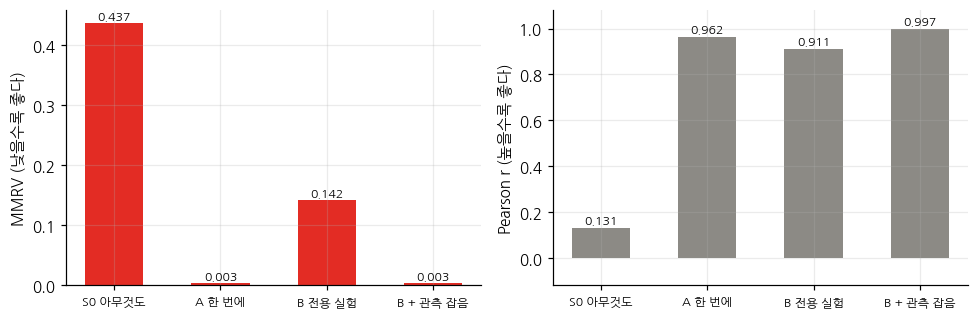

In [13]:
mm = [score[s][0] for s in labels]
pr = [score[s][1] for s in labels]
x = np.arange(len(labels))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(9.0, 3.0))
a1.bar(x, mm, color=RED, width=.55)
a1.set_ylabel("MMRV (낮을수록 좋다)")
for i, v in enumerate(mm):
    a1.text(i, v + .006, f"{v:.3f}", ha="center", fontsize=8)
a2.bar(x, pr, color=GREY, width=.55)
a2.set_ylabel("Pearson r (높을수록 좋다)")
a2.set_ylim(min(0, min(pr)) - .12, 1.08)
for i, v in enumerate(pr):
    a2.text(i, v + .02, f"{v:.3f}", ha="center", fontsize=8)
for a in (a1, a2):
    a.set_xticks(x)
    a.set_xticklabels(labels, fontsize=8)
plt.tight_layout()
plt.show()

## 정리

**손실 지형을 먼저 그려 본다.** 추정을 돌리기 전에 파라미터 하나씩 훑어 보면 두 가지가 보인다. 골짜기가 얕으면 그 파라미터는 이 실험에서 되찾히지 않고, 골짜기가 울퉁불퉁하면 최소점이 참값에 있다는 보장이 없다. 접촉이 있는 시스템에서는 후자가 흔하다.

**실험 설계가 옵티마이저보다 중요하다.** 같은 CEM으로 같은 궤적 수를 써도, 세 파라미터를 한 실험에 뒤섞으면 마찰이 크게 밀리고 파라미터마다 전용 실험을 만들면 참값에 붙는다. 마찰을 재려면 마찰만 작용하는 상황을, 액추에이터를 재려면 접촉이 없는 상황을 만든다.

**파라미터 오차는 목적이 아니라 중간 지표다.** 세 파라미터를 0% 오차로 되찾은 시뮬이 마찰을 30% 틀린 시뮬보다 MMRV가 나빴다. 모델에 없는 항(여기서는 관측 잡음)이 남아 있으면 파라미터를 아무리 정확히 맞춰도 순위가 어긋나고, 반대로 다른 파라미터가 그 빠진 항을 우연히 대신하면 틀린 값이 좋아 보인다.

**그러니 시스템 식별은 값을 맞추는 일이 아니라 모델의 구조를 맞추는 일이다.** 무엇을 빠뜨렸는지 찾는 것이 어느 값을 더 정밀하게 다듬을지보다 먼저다. 그리고 그것을 알려 주는 것은 파라미터 오차가 아니라 3장의 자다.

다음 장은 시스템 식별로도 안 없어지는 차이를 다룬다. 모델을 고치는 대신 **차이만 따로 배우는** 길이다.